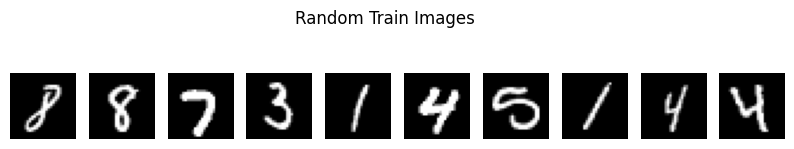

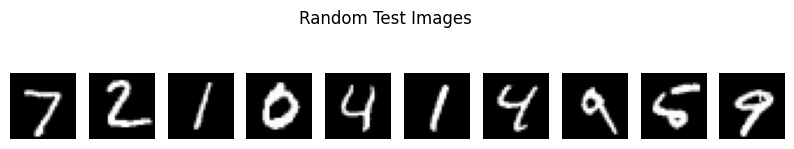

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),
])

batch_size = 64

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

def show_images(images, title="Images"):
    grid_img = images.detach().cpu().numpy()
    grid_img = grid_img.transpose(0, 2, 3, 1)
    
    plt.figure(figsize=(10, 2))
    for i in range(min(10, len(images))):
        plt.subplot(1, 10, i + 1)
        plt.imshow(grid_img[i].squeeze(), cmap='gray')
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

data_iter = iter(train_loader)
images, _ = next(data_iter)
show_images(images, title="Random Train Images")

test_iter = iter(test_loader)
images_test, _ = next(test_iter)
show_images(images_test, title="Random Test Images")

In [2]:
class EBM_Network(nn.Module):
    def __init__(self):
        super(EBM_Network, self).__init__()
        
        # Row 1: Conv2d(1->32, k=3, s=1, p=1) + LeakyReLU(0.2)
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(0.2)
        )
        # Row 2: Conv2d(32->32, k=4, s=2, p=1) + LeakyReLU(0.2) -> Output: 14x14
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 32, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2)
        )
        # Row 3: Conv2d(32->64, k=3, s=1, p=1) + LeakyReLU(0.2)
        self.layer3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(0.2)
        )
        # Row 4: Conv2d(64->64, k=4, s=2, p=1) + LeakyReLU(0.2) -> Output: 7x7
        self.layer4 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2)
        )
        # Row 5: Conv2d(64->128, k=3, s=1, p=1) + LeakyReLU(0.2)
        self.layer5 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(0.2)
        )
        # Row 6: AdaptiveAvgPool2d(output_size=1) -> Output: (B, 128, 1, 1)
        self.pool = nn.AdaptiveAvgPool2d(1)
        
        # Row 7 & 8: Flatten -> Linear(128 -> 1)
        self.linear = nn.Linear(128, 1)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.layer5(out)
        out = self.pool(out)
        out = out.view(out.shape[0], -1) # Flatten
        energy = self.linear(out)
        return energy

def langevin_sampling(model, x_curr, steps=60, step_size=10, noise_scale=0.005, return_traj=False):
    
    x_curr = x_curr.clone().detach().to(device)
    x_curr.requires_grad = True
    
    trajectory = []
    
    for i in range(steps):
        energy = model(x_curr)
        grad = torch.autograd.grad(energy.sum(), x_curr)[0]
        
        with torch.no_grad():
            noise = torch.randn_like(x_curr) * noise_scale
            x_curr = x_curr - step_size * grad + noise

            x_curr.clamp_(0, 1) 
            
        x_curr.requires_grad = True
        
        if return_traj:
            trajectory.append(x_curr.detach().cpu())
            
    if return_traj:
        return x_curr.detach(), trajectory
    return x_curr.detach()

Starting Training...
Epoch [1/10], Step [0], Data Loss: 0.0008, Reg Loss: 0.0000, E_real: -0.0078, E_fake: -0.0086
Epoch [1/10], Step [200], Data Loss: -0.0831, Reg Loss: 0.0026, E_real: -1.1297, E_fake: -1.0466
Epoch [1/10], Step [400], Data Loss: -0.2097, Reg Loss: 0.0012, E_real: -0.7756, E_fake: -0.5659
Epoch [1/10], Step [600], Data Loss: 0.1764, Reg Loss: 0.0008, E_real: -0.4410, E_fake: -0.6174
Epoch [1/10], Step [800], Data Loss: -0.5856, Reg Loss: 0.0009, E_real: -0.8142, E_fake: -0.2285
--- Generated Samples at Epoch 1 ---


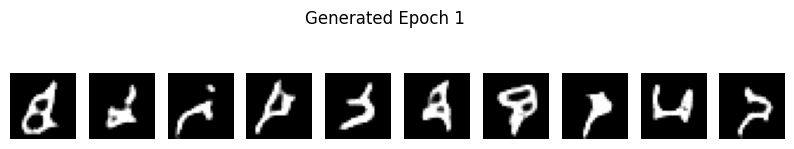

Epoch [2/10], Step [0], Data Loss: -0.0977, Reg Loss: 0.0006, E_real: -0.4649, E_fake: -0.3673
Epoch [2/10], Step [200], Data Loss: -0.0147, Reg Loss: 0.0033, E_real: -1.2621, E_fake: -1.2474
Epoch [2/10], Step [400], Data Loss: -0.2774, Reg Loss: 0.0016, E_real: -0.9816, E_fake: -0.7042
Epoch [2/10], Step [600], Data Loss: -0.3208, Reg Loss: 0.0004, E_real: -0.5356, E_fake: -0.2149
Epoch [2/10], Step [800], Data Loss: -0.1877, Reg Loss: 0.0018, E_real: -1.0069, E_fake: -0.8193
Epoch [3/10], Step [0], Data Loss: 0.0399, Reg Loss: 0.0012, E_real: -0.6914, E_fake: -0.7314
Epoch [3/10], Step [200], Data Loss: -0.0058, Reg Loss: 0.0010, E_real: -0.6864, E_fake: -0.6806
Epoch [3/10], Step [400], Data Loss: -0.0843, Reg Loss: 0.0002, E_real: -0.2409, E_fake: -0.1566
Epoch [3/10], Step [600], Data Loss: 0.0640, Reg Loss: 0.0002, E_real: -0.1862, E_fake: -0.2502
Epoch [3/10], Step [800], Data Loss: 0.0283, Reg Loss: 0.0001, E_real: -0.1256, E_fake: -0.1539
Epoch [4/10], Step [0], Data Loss: 0.

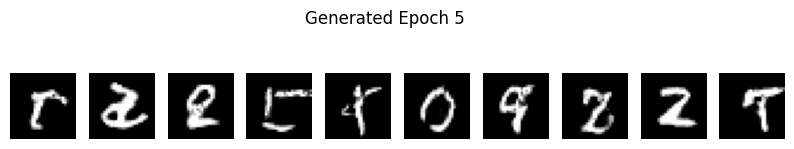

Epoch [6/10], Step [0], Data Loss: -0.0410, Reg Loss: 0.0001, E_real: 0.0489, E_fake: 0.0899
Epoch [6/10], Step [200], Data Loss: 0.0455, Reg Loss: 0.0001, E_real: -0.1238, E_fake: -0.1693
Epoch [6/10], Step [400], Data Loss: -0.0231, Reg Loss: 0.0001, E_real: -0.0970, E_fake: -0.0739
Epoch [6/10], Step [600], Data Loss: 0.0945, Reg Loss: 0.0001, E_real: 0.1775, E_fake: 0.0830
Epoch [6/10], Step [800], Data Loss: -0.0707, Reg Loss: 0.0001, E_real: -0.0260, E_fake: 0.0448
Epoch [7/10], Step [0], Data Loss: -0.0031, Reg Loss: 0.0001, E_real: 0.0709, E_fake: 0.0740
Epoch [7/10], Step [200], Data Loss: 0.0565, Reg Loss: 0.0001, E_real: 0.1467, E_fake: 0.0903
Epoch [7/10], Step [400], Data Loss: 0.0599, Reg Loss: 0.0001, E_real: -0.0484, E_fake: -0.1082
Epoch [7/10], Step [600], Data Loss: -0.0425, Reg Loss: 0.0001, E_real: 0.0756, E_fake: 0.1181
Epoch [7/10], Step [800], Data Loss: 0.0128, Reg Loss: 0.0001, E_real: -0.0665, E_fake: -0.0794
Epoch [8/10], Step [0], Data Loss: 0.0414, Reg Los

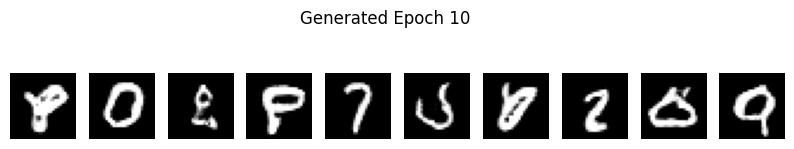

Training Finished.


In [3]:
num_epochs = 10
lr = 1e-4
lambda_reg = 1e-3
langevin_steps = 60
langevin_step_size = 10
langevin_noise = 0.005 

model = EBM_Network().to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)

print("Starting Training...")

for epoch in range(num_epochs):
    epoch_loss_data = 0
    epoch_loss_reg = 0
    
    for i, (real_imgs, _) in enumerate(train_loader):
        batch_size = real_imgs.size(0)
        real_imgs = real_imgs.to(device)
        
        e_real = model(real_imgs) # (B, 1)
        
        noise_init = torch.rand_like(real_imgs).to(device) 

        fake_imgs = langevin_sampling(model, noise_init, 
                                      steps=langevin_steps, 
                                      step_size=langevin_step_size, 
                                      noise_scale=langevin_noise)
        
        fake_imgs.requires_grad = True 
        
        e_fake = model(fake_imgs)
        
        loss_data = e_real.mean() - e_fake.mean()

        loss_reg = lambda_reg * ( (e_real**2).mean() + (e_fake**2).mean() )
        
        loss = loss_data + loss_reg
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss_data += loss_data.item()
        epoch_loss_reg += loss_reg.item()
        
        if i % 200 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i}], "
                  f"Data Loss: {loss_data.item():.4f}, Reg Loss: {loss_reg.item():.4f}, "
                  f"E_real: {e_real.mean().item():.4f}, E_fake: {e_fake.mean().item():.4f}")

    if (epoch+1) % 5 == 0 or epoch == 0:
        print(f"--- Generated Samples at Epoch {epoch+1} ---")
        show_images(fake_imgs.detach().cpu(), title=f"Generated Epoch {epoch+1}")

print("Training Finished.")

In [ ]:
torch.save(model.state_dict(), 'EBM_final.pth')
print("Model weights saved.")

Model weights saved.


--- Step 1: Real Train Images (Start Points) ---


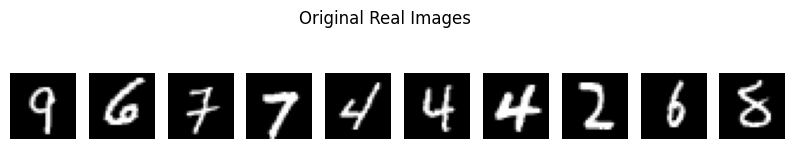

--- Step 2: Output after Langevin Sampling ---


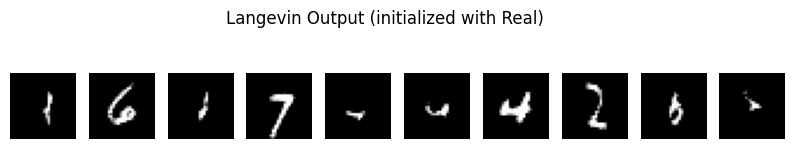

In [11]:
real_batch, _ = next(iter(train_loader))
real_batch = real_batch[:16].to(device)

print("--- Step 1: Real Train Images (Start Points) ---")
show_images(real_batch.cpu(), title="Original Real Images")

refined_real = langevin_sampling(model, real_batch, 
                                 steps=60,
                                 step_size=5,
                                 noise_scale=0.005)

print("--- Step 2: Output after Langevin Sampling ---")
show_images(refined_real.cpu(), title="Langevin Output (initialized with Real)")

Final Generated Samples:


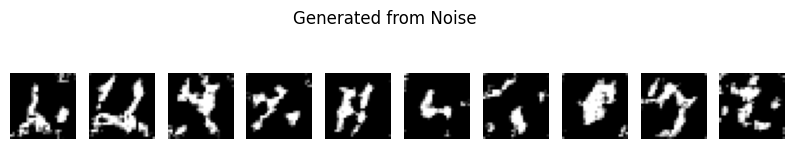

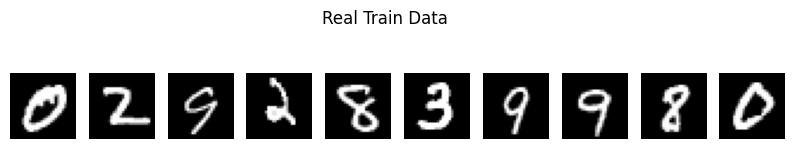

In [25]:
num_samples = 16
noise_start = torch.rand(num_samples, 1, 28, 28).to(device)

generated_samples = langevin_sampling(model, noise_start, 
                                      steps=120,
                                      step_size=4, 
                                      noise_scale=0.005)

print("Final Generated Samples:")
show_images(generated_samples.cpu(), title="Generated from Noise")

real_batch, _ = next(iter(train_loader))
show_images(real_batch[:16], title="Real Train Data")


--- Denoising with Noise Level: 0.2 ---


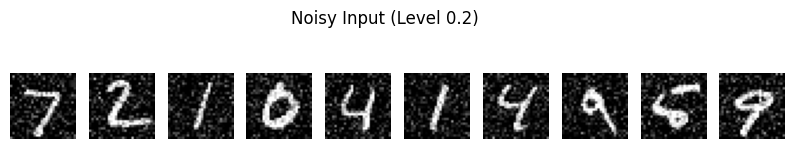

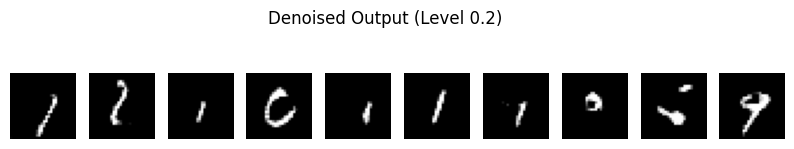

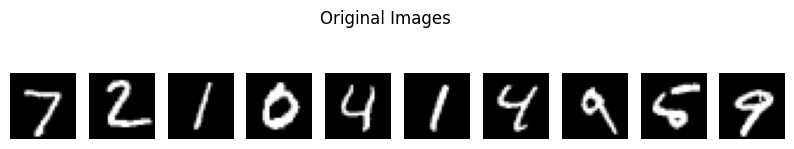


--- Denoising with Noise Level: 0.4 ---


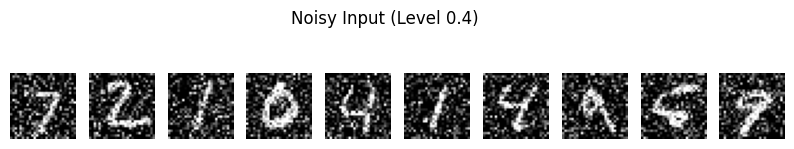

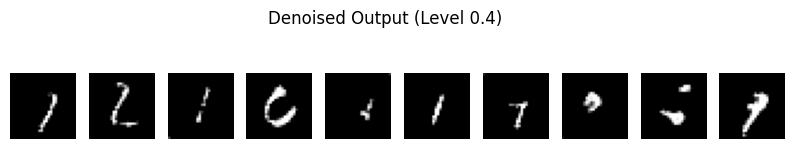

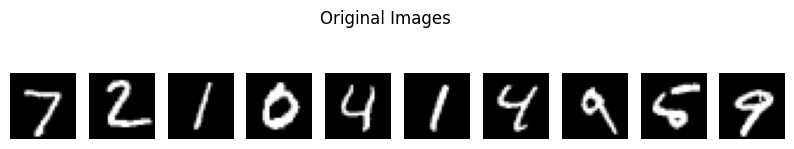


--- Denoising with Noise Level: 0.6 ---


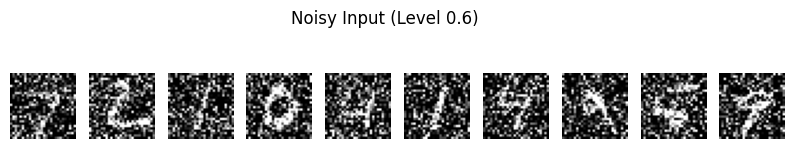

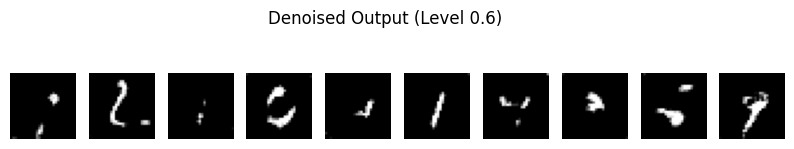

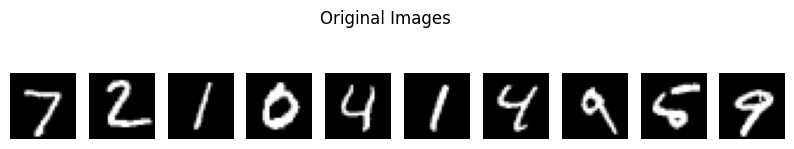

In [28]:
def add_noise(images, noise_level):
    return torch.clamp(images + noise_level * torch.randn_like(images), 0, 1)

test_imgs, _ = next(iter(test_loader))
test_imgs = test_imgs[:16].to(device)

noise_levels = [0.2, 0.4, 0.6]

for nl in noise_levels:
    print(f"\n--- Denoising with Noise Level: {nl} ---")
    
    noisy_imgs = add_noise(test_imgs, nl)
    
    show_images(noisy_imgs.cpu(), title=f"Noisy Input (Level {nl})")
    
    denoised_imgs = langevin_sampling(model, noisy_imgs, 
                                      steps=60, 
                                      step_size=5, 
                                      noise_scale=0.005)

    show_images(denoised_imgs.cpu(), title=f"Denoised Output (Level {nl})")
    show_images(test_imgs.cpu(), title="Original Images")